In [5]:
import pandas as pd
import numpy as np

In [6]:
data=pd.read_csv('Churn_Modelling.csv')

In [7]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
data.duplicated().sum()

0

In [10]:
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [11]:
data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [12]:
data.drop(columns=['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [13]:
data=pd.get_dummies(data,columns=['Geography','Gender'],drop_first=True)

In [14]:
x=data.drop(columns=['Exited'])
y=data['Exited']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [17]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [18]:
model=Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [21]:
history=model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7155 - loss: 0.5550 - val_accuracy: 0.8012 - val_loss: 0.4583
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8005 - loss: 0.4464 - val_accuracy: 0.8044 - val_loss: 0.4414
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8064 - loss: 0.4311 - val_accuracy: 0.8087 - val_loss: 0.4307
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8166 - loss: 0.4202 - val_accuracy: 0.8206 - val_loss: 0.4194
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8291 - loss: 0.4080 - val_accuracy: 0.8288 - val_loss: 0.4045
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8378 - loss: 0.3938 - val_accuracy: 0.8313 - val_loss: 0.3899
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8441 - loss: 0.3807 - val_accuracy: 0.8381 - val_loss: 0.3784
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8495 - loss: 0.3702 - val_accu

In [22]:
model.layers[0].get_weights()

[array([[ 3.89165580e-02,  7.42471889e-02,  3.03879768e-01,
         -2.16456443e-01,  8.02016333e-02,  3.54038388e-01,
         -9.72809345e-02,  8.33603218e-02, -1.03761598e-01,
         -7.34036118e-02, -1.44043595e-01],
        [ 1.97031662e-01,  2.40638986e-01, -3.04675043e-01,
          1.12206422e-01, -2.49117553e-01, -7.68487230e-02,
         -3.45195867e-02, -6.72162950e-01,  7.19662964e-01,
          1.32394934e+00,  9.12797034e-01],
        [-5.63488491e-02, -1.67625904e-01, -2.79556692e-01,
         -2.30812848e-01, -1.97935075e-01, -1.60840437e-01,
          6.97022006e-02, -4.03991252e-01, -1.44211158e-01,
         -1.09795362e-01,  3.81382644e-01],
        [-1.09203660e+00,  4.01141375e-01, -2.08666220e-01,
          5.00797331e-01, -5.55338740e-01,  9.70861316e-01,
          4.82625887e-02,  2.11876497e-01,  1.20666444e-01,
          3.11482489e-01, -4.41274941e-01],
        [-2.07507998e-01,  1.04035962e+00,  9.91529644e-01,
         -4.21825498e-01,  8.86899292e-01, -

In [23]:
model.layers[1].get_weights()

[array([[-6.01327181e-01,  6.25504106e-02, -1.08997114e-01,
          3.38183671e-01,  2.43134573e-01,  3.41703564e-01,
          4.30858254e-01, -2.51477450e-01,  3.20638329e-01,
          4.68691513e-02,  5.38486063e-01],
        [ 7.05625951e-01, -5.23664474e-01,  7.06796706e-01,
         -6.42463565e-01,  8.48138332e-02, -1.04060006e+00,
         -1.17486346e+00, -7.36825109e-01, -4.05935913e-01,
         -9.21623185e-02,  6.08003233e-04],
        [-8.32159072e-02, -1.37778252e-01, -1.26426160e-01,
          4.25040215e-01, -3.39925230e-01, -3.80830228e-01,
         -4.68638897e-01,  6.64886609e-02, -4.05374877e-02,
         -8.61249030e-01, -1.14160454e+00],
        [ 4.77842152e-01, -2.02868357e-01,  6.85702384e-01,
          1.78256318e-01,  6.40275478e-01,  3.09048176e-01,
          3.03913742e-01, -5.38772821e-01,  6.41624212e-01,
         -3.60748798e-01, -2.05740601e-01],
        [ 9.74265561e-02,  5.84270060e-02, -4.24689740e-01,
          6.02997363e-01,  6.77658916e-01, -

In [24]:
y_log=model.predict(x_test_scaled)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.02639423],
       [0.07476754],
       [0.04039851],
       ...,
       [0.0051756 ],
       [0.00953951],
       [0.4507469 ]], dtype=float32)

In [25]:
y_pred=np.where(y_log>0.5,1,0)

In [26]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [27]:
from sklearn.metrics import accuracy_score

In [28]:
accuracy_score(y_test,y_pred)

0.8615

In [29]:
import matplotlib.pyplot as plt

In [30]:
history.history

{'accuracy': [0.7154687643051147,
  0.8004687428474426,
  0.8064062595367432,
  0.8165624737739563,
  0.8290625214576721,
  0.8378124833106995,
  0.8440625071525574,
  0.8495312333106995,
  0.8501562476158142,
  0.8518750071525574,
  0.8573437333106995,
  0.8600000143051147,
  0.8600000143051147,
  0.8603125214576721,
  0.8612499833106995,
  0.8621875047683716,
  0.8610937595367432,
  0.8620312213897705,
  0.8609374761581421,
  0.8614062666893005,
  0.8600000143051147,
  0.8617187738418579,
  0.8626562356948853,
  0.8635937571525574,
  0.8629687428474426,
  0.8609374761581421,
  0.8620312213897705,
  0.8634374737739563,
  0.8629687428474426,
  0.862500011920929,
  0.8629687428474426,
  0.8650000095367432,
  0.8621875047683716,
  0.864062488079071,
  0.8637499809265137,
  0.8620312213897705,
  0.862500011920929,
  0.8643749952316284,
  0.8642187714576721,
  0.8642187714576721,
  0.8650000095367432,
  0.8657812476158142,
  0.8653125166893005,
  0.8660937547683716,
  0.8651562333106995,
 

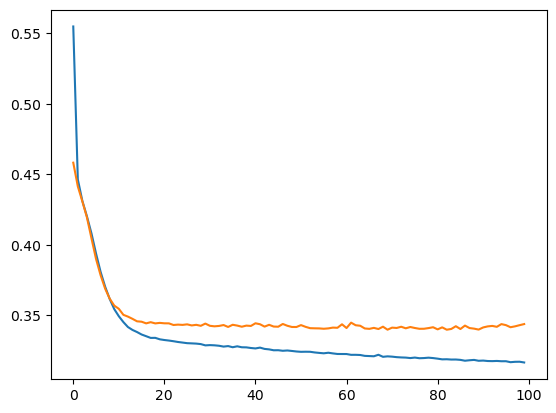

In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

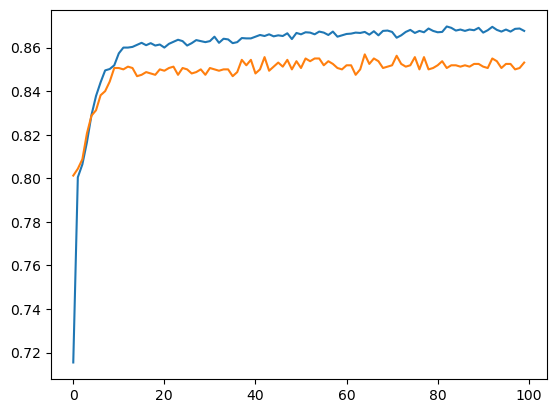

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])